In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
import sqlite3 
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [1]:
!pip install scipy


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv(r'C:\Users\Karan\Downloads\Messy_Employee_dataset_2.csv')
df

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,0,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1004,Frank,Williams,25,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False
3,EMP1011,David,Davis,0,DevOps-California,Active,9/4/2023,84946.19,david.davis@example.com,-1238296576,Poor,True
4,EMP1014,Alice,Garcia,25,Admin-Nevada,Active,6/10/2024,97633.68,alice.garcia@example.com,-1734206968,Excellent,True
...,...,...,...,...,...,...,...,...,...,...,...,...
198,EMP1995,Bob,Jones,30,Finance-California,Inactive,8/16/2023,61240.90,bob.jones@example.com,-2007843613,Poor,True
199,EMP2002,Bob,Smith,35,Finance-Illinois,Pending,6/29/2020,63049.22,bob.smith@example.com,-586950731,Good,True
200,EMP2003,Frank,Smith,35,HR-California,Pending,2/15/2023,115229.12,frank.smith@example.com,-1464493698,Excellent,True
201,EMP2006,Grace,Brown,0,HR-Illinois,Inactive,10/25/2023,77821.79,grace.brown@example.com,-119236036,Average,False


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,203.0,2.539409e+01,1.459324e+01,0.000000e+00,2.500000e+01,3.000000e+01,3.500000e+01,40.00
Salary,203.0,8.410454e+04,2.083175e+04,5.011066e+04,6.458765e+04,8.538858e+04,1.007966e+05,119152.47
Phone,203.0,-1.087516e+09,6.485613e+08,-2.146296e+09,-1.619140e+09,-1.128981e+09,-6.063892e+08,0.00


In [7]:

print(df.columns)

Index(['Employee_ID', 'First_Name', 'Last_Name', 'Age', 'Department_Region',
       'Status', 'Join_Date', 'Salary', 'Email', 'Phone', 'Performance_Score',
       'Remote_Work'],
      dtype='object')


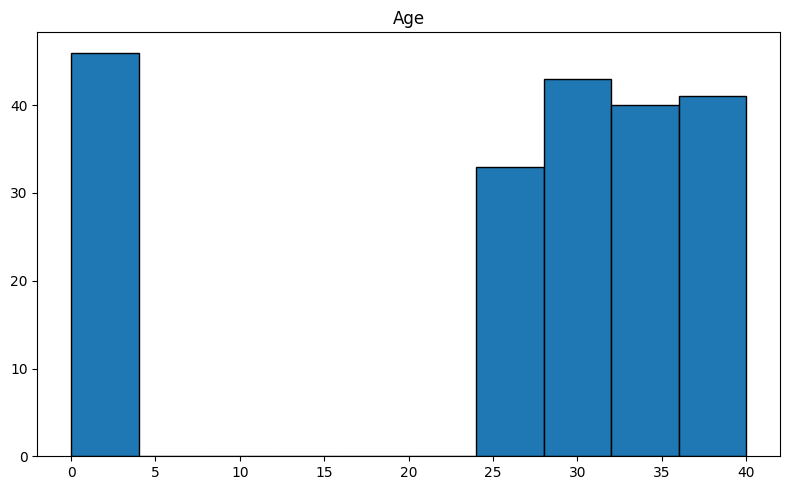

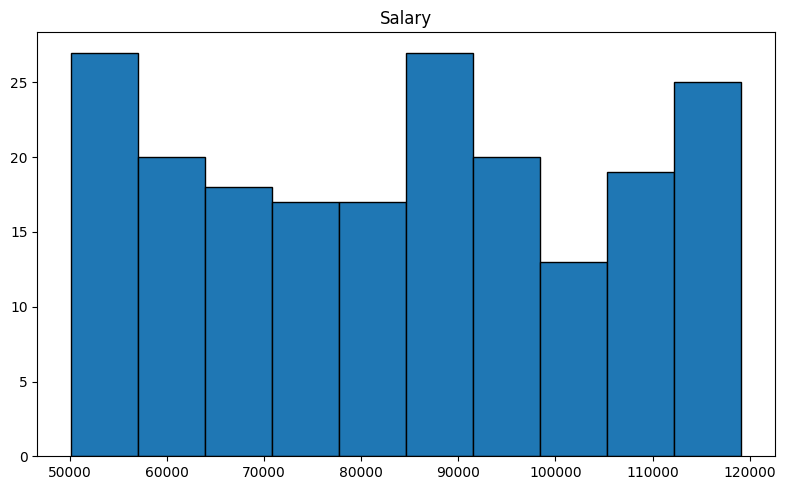

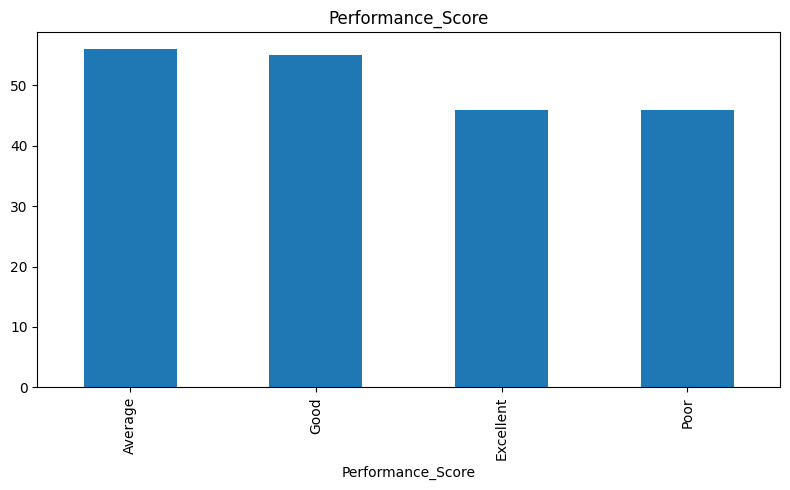

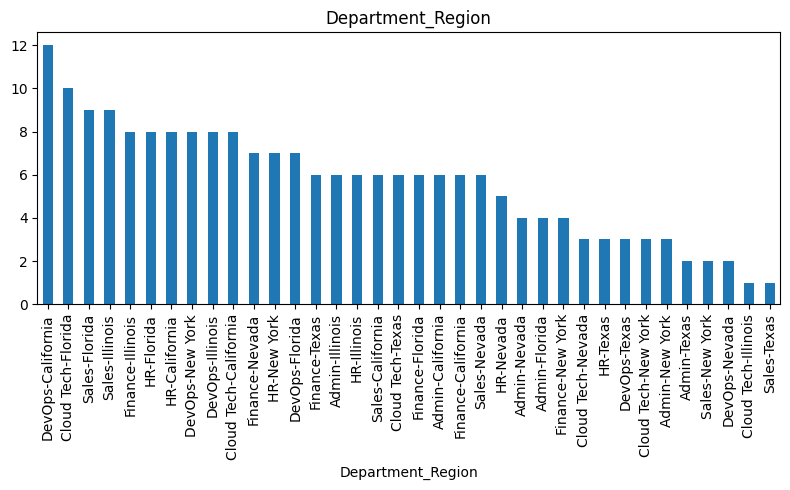

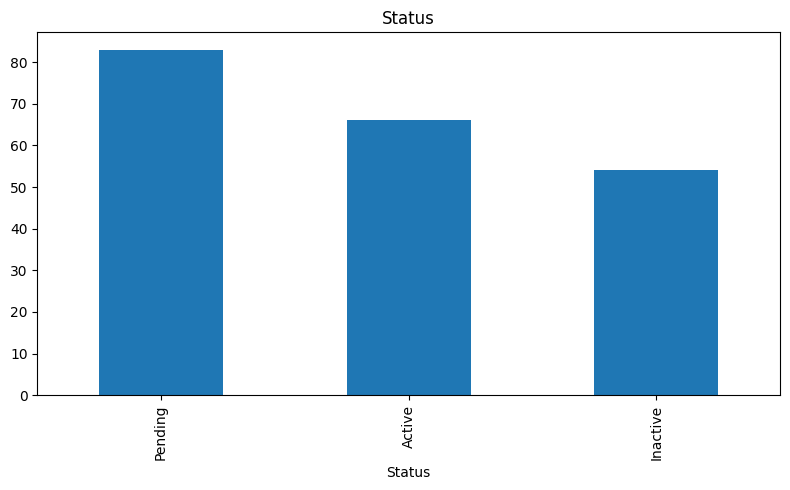

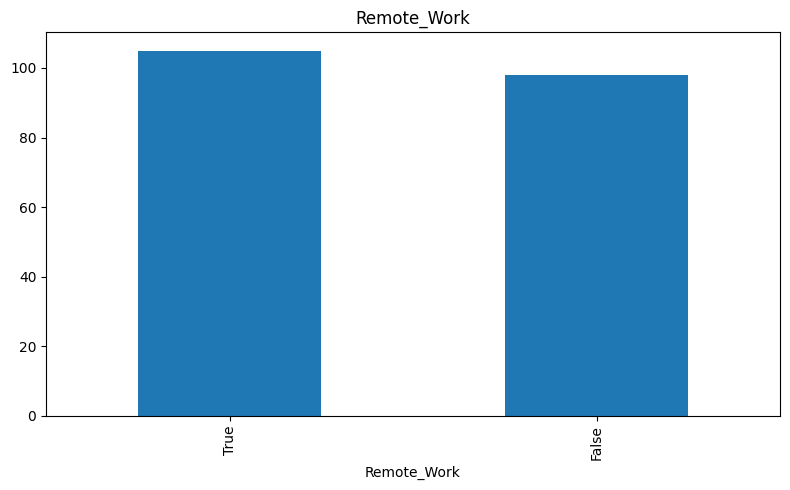

In [8]:
cols_to_plot = [
    'Age',
    'Salary',
    'Performance_Score',
    'Department_Region',
    'Status',
    'Remote_Work'
]

for col in cols_to_plot:
    plt.figure(figsize=(8,5))

    if df[col].dtype in ['int64', 'float64']:
        plt.hist(df[col], bins=10, edgecolor='black')
    else:
        df[col].value_counts().plot(kind='bar')

    plt.title(col)
    plt.tight_layout()
    plt.show()

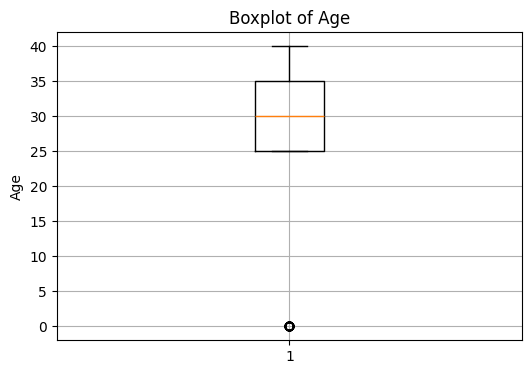

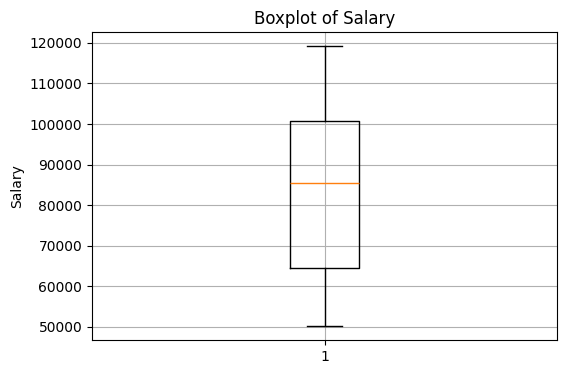

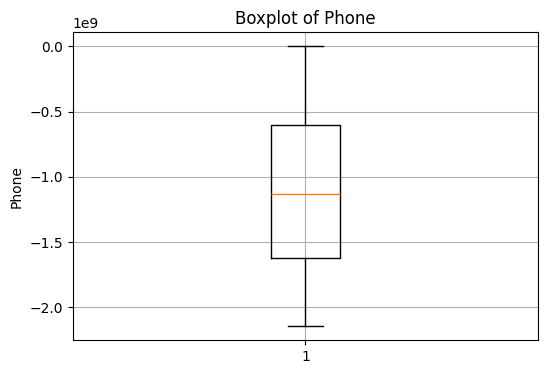

In [9]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

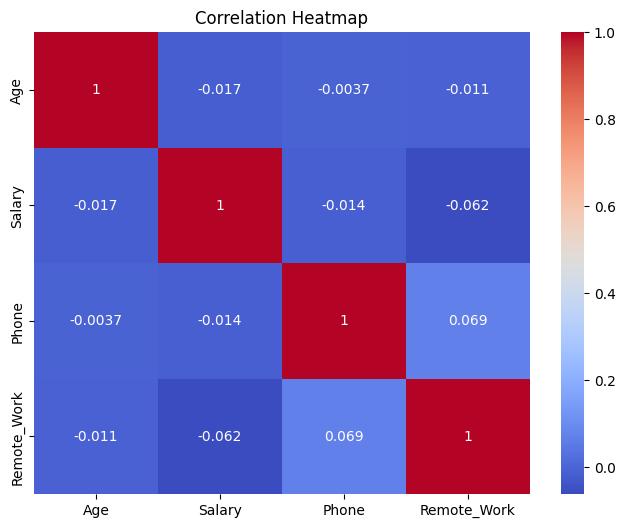

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

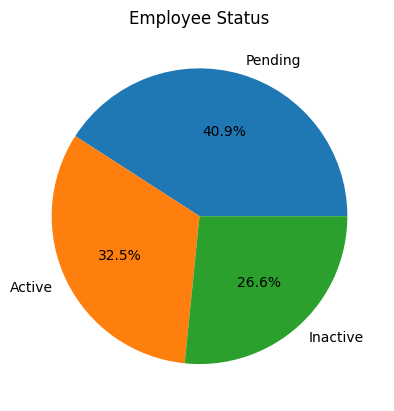

In [11]:
df['Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.title("Employee Status")
plt.show()

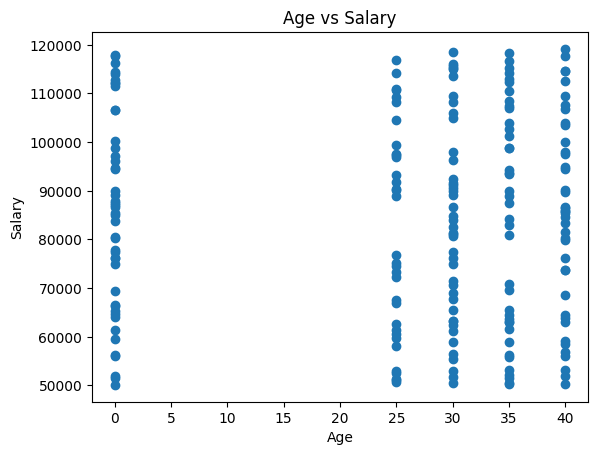

In [12]:
plt.scatter(df['Age'], df['Salary'])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

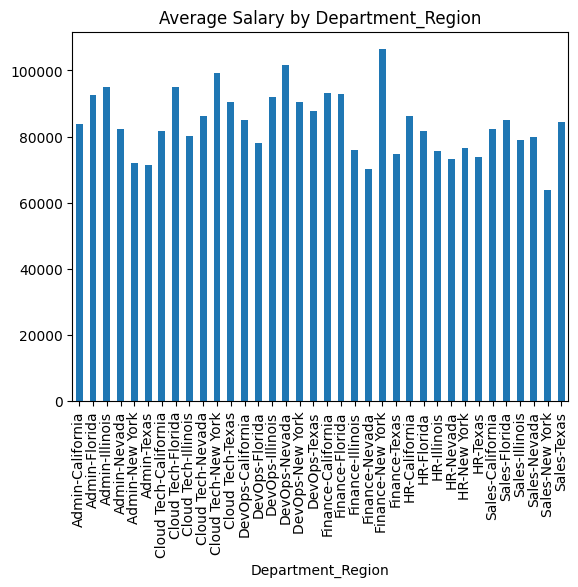

In [14]:
df.groupby('Department_Region')['Salary'].mean().plot(kind='bar')
plt.title("Average Salary by Department_Region")
plt.show()

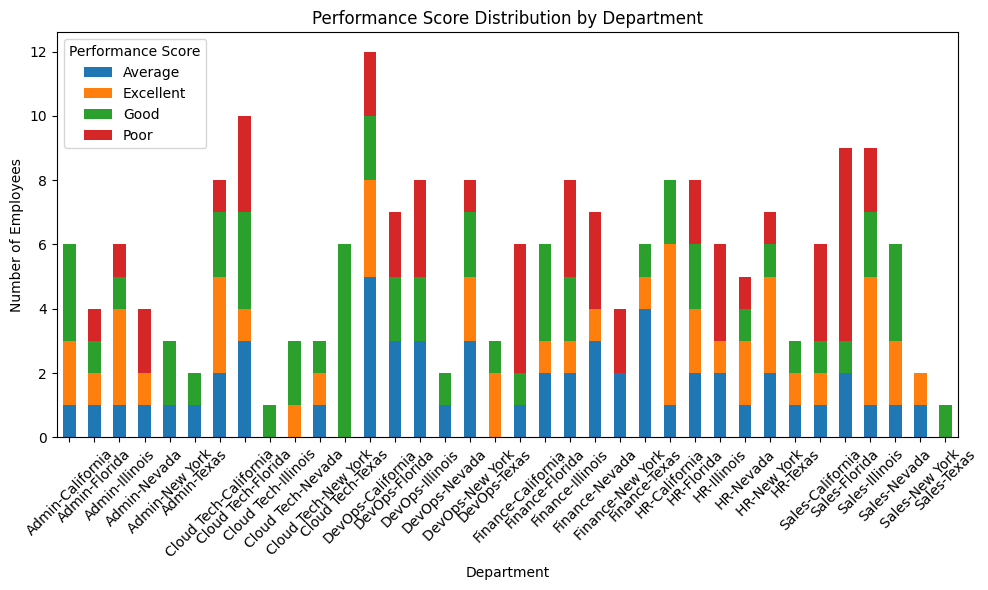

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

performance_dept = pd.crosstab(df['Department_Region'],
                               df['Performance_Score'])

performance_dept.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Performance Score Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.legend(title='Performance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
score_map = {
    'Poor': 1,
    'Average': 2,
    'Good': 3,
    'Excellent': 4
}

df['Performance_Num'] = df['Performance_Score'].map(score_map)

print(
    df.groupby('Remote_Work')['Performance_Num'].mean()
)

Remote_Work
False    2.510204
True     2.485714
Name: Performance_Num, dtype: float64


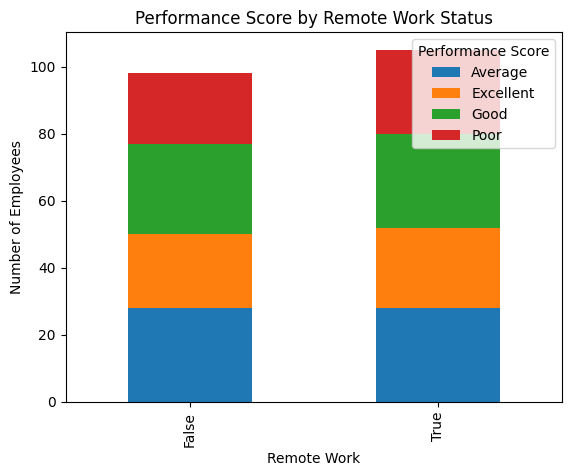

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

perf_remote = pd.crosstab(
    df['Remote_Work'],
    df['Performance_Score']
)

perf_remote.plot(kind='bar', stacked=True)

plt.title('Performance Score by Remote Work Status')
plt.xlabel('Remote Work')
plt.ylabel('Number of Employees')
plt.legend(title='Performance Score')
plt.show()